# Taller 3: Exploratory Data Analysis (EDA) y Data Wrangling

## Introducción

Instacart es una plataforma de entrega de comestibles donde los clientes pueden hacer un pedido y recibirlo, de manera similar a como funcionan Uber Eats y Door Dash.
El conjunto de datos que se te ha proporcionado ha sido modificado del original. Hemos reducido el tamaño del conjunto para que tus cálculos se ejecuten más rápido y hemos introducido deliberadamente valores ausentes (missing values) y duplicados. Sin embargo, hemos conservado las distribuciones poblacionales de los datos originales.

**Tu misión profesional:** Como Científico de Datos, aplicarás metodológicamente las 4 dimensiones de la calidad de los datos para auditar tu dataset. Luego, realizarás un análisis exploratorio empleando medidas de tendencia central, variabilidad, diagramas de dispersión, y responderás preguntas de negocio tras construir una tabla desnormalizada (One Big Table - OBT).

> **Aviso Importante:** Para cada paso, escribe introducciones donde expongas qué harás, bloques intermedios justificando el porqué de tus decisiones y tu limpieza estadística, y cierra siempre con una conclusión de lo hallado.

## Diccionario de Datos

Hay cinco tablas en el conjunto de datos que deberás usar en conjunto:

- `instacart_orders.csv`: cada fila es un pedido en la app de Instacart
    - `'order_id'`: ID que identifica de manera única cada pedido
    - `'user_id'`: ID que identifica de manera única a cada cliente
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 es domingo)
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido
    - `'days_since_prior_order'`: número de días desde que este cliente hizo su último pedido
- `products.csv`: cada fila corresponde a un producto
    - `'product_id'`: ID único del producto
    - `'product_name'`: nombre del producto
    - `'aisle_id'`: ID único de la categoría del pasillo
    - `'department_id'`: ID único de la categoría del departamento
- `order_products.csv`: cada fila corresponde a un artículo en un pedido
    - `'order_id'`: ID único del pedido
    - `'product_id'`: ID único del producto
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo al carrito
    - `'reordered'`: 0 si el cliente no había pedido este producto antes, 1 si ya lo había hecho
- `aisles.csv`
    - `'aisle_id'`: ID único del pasillo
    - `'aisle'`: nombre del pasillo
- `departments.csv`
    - `'department_id'`: ID único del departamento
    - `'department'`: nombre del departamento

# Paso 1: Exploración Inicial

Lee los archivos ubicados en el directorio `/datos/` (`instacart_orders.csv`, `products.csv`, `aisles.csv`, `departments.csv` y `order_products.csv`) fijándote que algunos están separados por `;` u otros delimitadores. 

Tras leerlos, ejecuta funciones de inspección básica (`head()`, `info()`) y comprueba una muestra aleatoria (Muestreo Aleatorio Simple usando `sample()`) de cada tabla para evitar el *sesgo de posición*. Verifica si los tipos computacionales coinciden con su rol estadístico esperado.

In [1]:
# Importación de librerias y modulos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Carga de archivos de datos
orders=pd.read_csv('./datos/instacart_orders.csv', sep=';')
products=pd.read_csv('./datos/products.csv', sep=';')
aisles=pd.read_csv('./datos/aisles.csv', sep=';')
departments=pd.read_csv('./datos/departments.csv', sep=';')
order_products=pd.read_csv('./datos/order_products.csv', sep=';')

In [3]:
# Iteración sobre los dataframes para mostrar información relevante
for nombre, df in [('orders', orders), ('products', products),
                   ('aisles', aisles), ('departments', departments),
                   ('order_products', order_products)]:

    print(f"TABLA: {nombre}\n")
    print(f"Encabezado de la tabla {nombre}:\n")
    print(df.head())
    print()          
    print(f"Información de la tabla {nombre}:\n")
    print(df.info())     
    print()     
    print(f"Muestra aleatoria de la tabla {nombre}:\n")
    print(df.sample(20))        
    print()
    print(f"Dimensiones de la tabla {nombre}:")
    print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
    print()

TABLA: orders

Encabezado de la tabla orders:

   order_id  user_id  order_number  order_dow  order_hour_of_day  \
0   1515936   183418            11          6                 13   
1   1690866   163593             5          5                 12   
2   1454967    39980             4          5                 19   
3   1768857    82516            56          0                 20   
4   3007858   196724             2          4                 12   

   days_since_prior_order  
0                    30.0  
1                     9.0  
2                     2.0  
3                    10.0  
4                    17.0  

Información de la tabla orders:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_numbe

### Escribe tus hallazgos iniciales aquí:
(Escribe textualmente qué dimensiones, tipos de datos ves incoherentes y qué opinas estadísticamente de la primera radiografía de los datos).

Las dimensiones de los datos son los siguientes:

- orders: 478967 filas × 6 columnas

- products: 49694 filas × 4 columnas
    
- aisles: 134 filas × 2 columnas
    
- departments: 21 filas × 2 columnas
    
- order_products: 4545007 filas × 4 columnas 

Los dataset que presentan alguna incoherencia en su tipo de datos son:
    
- orders: *days_since_prior_order* debería ser entero (int64) y en este caso es float64, porque los días son números enteros
    
- order_products: *add_to_cart_order* es float64, cuando por la naturaleza de esa variable sería conveniente que sea un entero (int64)

Con respecto a un argumento estadístico de estos primeros hallazgos, las tablas **aisles** y **departments** son pequeñas y están limpias, denotando un control sobre estas por la poca cantidad de datos. Por otro lado, el resto de tablas presentan una cantidad de datos más robusta para un análiis estadístico así como detección de tendencias, patrones y distribuciones que colaboren en la toma de desiciones basadas en datos

# Paso 2: Auditoría de Calidad de Datos (4 Dimensiones)

Basado en la teoría vista, somete a tus 5 tablas al escrutinio en las cuatro dimensiones.

## 2.1 Precisión: Identificación y limpieza de duplicados explícitos e implícitos
Encuentra y elimina duplicados explícitos en la tabla de `orders`. Nota si se agrupan por algún motivo (¿Son de un día y hora en particular?). Asimismo, busca duplicados por ID de producto (tricky duplicates) o nombres duplicados con problemas de mayúsculas y minúsculas.

In [4]:
# Ver la cantida de duplicados explícitos en orders
dupl_orders = orders[orders.duplicated()]
print(f"Duplicados explícitos en orders: {len(dupl_orders)}")

# Ver los duplicados 
dupl_orders.head(15)

Duplicados explícitos en orders: 15


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
145574,794638,50898,24,3,2,2.0
223105,2160484,107525,16,3,2,30.0
230807,1918001,188546,14,3,2,16.0
266232,1782114,106752,1,3,2,NaN
273805,1112182,202304,84,3,2,6.0
284038,2845099,31189,11,3,2,7.0
311713,1021560,53767,3,3,2,9.0
321100,408114,68324,4,3,2,18.0
323900,1919531,191501,32,3,2,7.0
345917,2232988,82565,1,3,2,NaN


Se aprecia que los datos que tienen duplicados tienen un patrón, suceden los días Miércoles (Día 3) a las 2 am. Por lo podría suponerse que existe un bug en el servidor que toma los datos a esa hora.

Como se ve que tienen un patrón, una decisión inteligente sería **NO BORRARLOS** ya que presentan información útil para un mejoramiento en el sistema, ya con este hallazgo, el departamento de datos de la empresa podría verificar que está pasando y estudiar de mejor manera el caso. Si se los borra, se perdería esa información y el sistema de la aplicación seguiria con el problema.

In [5]:
# Verificar el ID y nombres en products

# Creación de una columna para comparar los nombres 
products['product_name_lower'] = products['product_name'].str.lower().str.strip()

# Ver los pares duplicados en product_name_lower (Se excluyen los nulos)
dupl_prod = products[
    products.duplicated(subset='product_name_lower', keep=False) & 
    products['product_name_lower'].notna() 
]

dupl_prod[['product_id', 'product_name', 'product_name_lower']].sort_values('product_name_lower').reset_index(drop=True)

,product_id,product_name,product_name_lower
0,23340,18-in-1 Hemp Peppermint Pure-Castile Soap,18-in-1 hemp peppermint pure-castile soap
1,31845,18-In-1 Hemp Peppermint Pure-Castile Soap,18-in-1 hemp peppermint pure-castile soap
2,19942,Aged Balsamic Vinegar Of Modena,aged balsamic vinegar of modena
3,13153,Aged Balsamic Vinegar of Modena,aged balsamic vinegar of modena
4,24831,Albacore Solid White Tuna in Water,albacore solid white tuna in water
...,...,...,...
202,46874,Vitamin D3 5000 IU,vitamin d3 5000 iu
203,21367,Wild Sardines in Spring Water,wild sardines in spring water
204,40094,Wild Sardines In Spring Water,wild sardines in spring water
205,1827,Yams Cut Sweet Potatoes in Syrup,yams cut sweet potatoes in syrup


In [6]:
# Duplicados por ID
dupl_prod_id = products[products.duplicated(subset='product_id', keep=False)]

dupl_prod_id[['product_id', 'product_name']].sort_values('product_id').reset_index(drop=True)

,product_id,product_name


Como se encuentran duplicados por product_name, se hará una homogenización de estos, y se conservará solo los nombres con el menor product_id

Ya que en teoria es el primero que se ingresó al sistema, por lo tanto sería el product_id original.

In [7]:
nans_df = products[products['product_name_lower'].isna()]
valid_df = products[products['product_name_lower'].notna()]

# homogenizar los validos
valid_df = (
    valid_df
    .sort_values('product_id')
    .drop_duplicates(subset='product_name_lower', keep='first')
)

# Unir todo nuevamente y limpiar la columna temporal
products = (
    pd.concat([valid_df, nans_df])
    .sort_values('product_id')          # Ordenar el dataset final por ID
    .drop(columns='product_name_lower') # Eliminar columna auxiliar de forma segura
    .reset_index(drop=True)             # Resetear el índice
)

products

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13
...,...,...,...,...
49585,49684,Vodka- Triple Distilled- Twist of Vanilla,124,5
49586,49685,En Croute Roast Hazelnut Cranberry,42,1
49587,49686,Artisan Baguette,112,3
49588,49687,Smartblend Healthy Metabolism Dry Cat Food,41,8


### Conclusiones sobre la Precisión:
Explica por qué eliminaste (o consolidaste) la información y qué nos enseña sobre la ingesta del sistema.

Los duplicados en orders se conservan deliberadamente. Al seguir un patrón no aleatorio (miércoles a las 2 AM), su eliminación implicaría pérdida de información potencialmente útil para auditoría del pipeline.

Los nombres de los productos duplicados se homogenizaron y se conservó el id menor, teniendo en cuenta que sería el valor canónico. Ya con eso, se establece una línea base para tener en cuenta que estos valores son los reales, para homogenizar la base de datos

## 2.2 Completitud: Tratamiento de Valores Ausentes
Navega por las tablas en busca de NaNs. Es crítico que analices si el patrón de valores ausentes se trata de MCAR (Missing Completely at Random), MAR o MNAR.

1. Revisa nombres de productos vacíos.
2. Revisa NaNs en `days_since_prior_order`. (¿Son clientes haciendo su primera orden?)
3. Revisa `add_to_cart_order` en `order_products`. (¿Qué pasa después de 64 artículos?)

Decide si debes imputar por tendencia central, usar ML, imputar un valor indicador ficticio (e.g. -1 o 'Desconocido') o eliminar las filas. ¡Aplica tus soluciones!

In [8]:
# 1. Visualizar las filas de nan 
nan_products = products[products['product_name'].isna()]

nan_products[['product_id', 'product_name']]

,product_id,product_name
37,38,NaN
71,72,NaN
109,110,NaN
296,297,NaN
416,417,NaN
...,...,...
49454,49553,NaN
49476,49575,NaN
49542,49641,NaN
49565,49664,NaN


In [9]:
# Eliminar filas con product_name NaN
products = products.dropna(subset=['product_name']).reset_index(drop=True)

products

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13
...,...,...,...,...
48327,49684,Vodka- Triple Distilled- Twist of Vanilla,124,5
48328,49685,En Croute Roast Hazelnut Cranberry,42,1
48329,49686,Artisan Baguette,112,3
48330,49687,Smartblend Healthy Metabolism Dry Cat Food,41,8


In [10]:
# 2. Visualizar las filas de nan en orders days_since_prior_order
nan_days = orders[orders['days_since_prior_order'].isna()]

nan_days[['order_id', 'user_id', 'order_number', 'days_since_prior_order']]

,order_id,user_id,order_number,days_since_prior_order
28,133707,182261,1,NaN
96,787445,25685,1,NaN
100,294410,111449,1,NaN
103,2869915,123958,1,NaN
104,2521921,42286,1,NaN
...,...,...,...,...
478895,2589657,205028,1,NaN
478896,2222353,141211,1,NaN
478922,2272807,204154,1,NaN
478926,2499542,68810,1,NaN


In [11]:
# Verificación si los NaN en days_since_prior_order corresponden a los primeros pedidos (order_number == 1)
verificacion = (nan_days['order_number']
                .value_counts()
                .reset_index()
                .rename(columns={'index': 'order_number', 'count': 'cantidad'}))

verificacion

,order_number,cantidad
0,1,28819


Es lógico que **days_since_prior_order** sea un valor nulo debido a que todos esos datos corresponden a un order_number de 1, que significa que es la primera vez. 
Por lo tanto, se procederá a imputar la información con un valor ficticio, que muestre esa discrepancia con los valores nulos y no borrar esas filas, se imputará con **-1**

In [14]:
orders['days_since_prior_order'] = orders['days_since_prior_order'].fillna(-1).astype(int) # Se transforma a entero para evitar problemas de tipo

orders[orders['order_number'] == 1]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
28,133707,182261,1,3,10,-1
96,787445,25685,1,6,18,-1
100,294410,111449,1,0,19,-1
103,2869915,123958,1,4,16,-1
104,2521921,42286,1,3,18,-1
...,...,...,...,...,...,...
478895,2589657,205028,1,0,16,-1
478896,2222353,141211,1,2,13,-1
478922,2272807,204154,1,1,15,-1
478926,2499542,68810,1,4,19,-1


In [15]:
# 3. Revisar add_to_cart_order > 64

order_products[order_products['add_to_cart_order'] > 64]

,order_id,product_id,add_to_cart_order,reordered


Sucede que pasado los 64 articulos, ya no genera mas datos, lo que quiere decir que hay un problema en la adquisición de la data pado los 64 articulos

### Conclusiones sobre la Completitud:
Argumenta qué mecanismo de ausencia (Rubin) encontraste en cada escenario y por qué tus estrategias de imputación no generaron sesgos severos.

En el caso de los nombres de productos vacíos que decidimos eliminar, nos enfrentamos a un mecanismo de pérdida completamente al azar, conocido como MCAR (Missing Completely at Random). Podemos argumentar que esta ausencia obedece a un error administrativo o del sistema desde el origen, ya que no hay evidencia de que los datos falten sistemáticamente por pertenecer a una categoría específica u oculta. Al aplicar la eliminación de estas filas bajo el supuesto MCAR, el único impacto real es una ligera reducción en el tamaño de la muestra

Por otro lado, los valores nulos en la columna de días desde la última orden responden a un mecanismo de pérdida al azar, o MAR (Missing at Random), operando específicamente como un faltante por diseño. La ausencia de este dato se explica en su totalidad por otra variable observable: el hecho de que el número de orden sea exactamente uno. Al ser la primera compra, es lógicamente imposible registrar un intervalo de tiempo previo. Imputar estos valores con un negativo uno fue una decisión algorítmica precisa para no generar sesgos, ya que aisla matemáticamente a este grupo. Si hubiéramos imputado con la media general o con un cero, habríamos distorsionado artificialmente el comportamiento real de los clientes recurrentes. El uso del '-1' actúa como una etiqueta categórica segura que protege la integridad de las métricas continuas

El hecho de que no existan registros mayores a 64 días no encaja en las definiciones de pérdida de Rubin, sino que representa un fenómeno de censura por la derecha o recorte de datos (data clipping). Esta limitación técnica del sistema no introduce un sesgo analítico perjudicial siempre y cuando este tope se modele e interprete de forma acumulativa como '64 días o más'.

## 2.3 Sensibilidad: Tratamiento de Outliers (Valores Atípicos)
Centra tu atención en la tabla de órdenes, específicamente en `days_since_prior_order` o conteos agrupados. Usando gráficos estadísticos (Boxplots) y computando el Rango Intercuartílico (IQR / Regla de Tukey) o Z-Scores, encuentra y reporta valores atípicos. ¿Existen usuarios que compran muy fuera del rango promedio de frecuencia?

In [21]:
# Filtrar day_since_prior_order == -1 para no tener sesgo
valid_days = orders[orders['days_since_prior_order'] != -1]

Q1 = valid_days['days_since_prior_order'].quantile(0.25)
Q3 = valid_days['days_since_prior_order'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


outliers = valid_days[
    (valid_days['days_since_prior_order'] < lower_bound) | 
    (valid_days['days_since_prior_order'] > upper_bound)
]

print(f"Estadísticas de la Regla de Tukey:")
print(f"  - Q1 (25%): {Q1} días")
print(f"  - Q3 (75%): {Q3} días")
print(f"  - Límite superior: {upper_bound} días")
print(f"  - Total de compras atípicas detectadas: {len(outliers)}\n")

Estadísticas de la Regla de Tukey:
  - Q1 (25%): 4.0 días
  - Q3 (75%): 15.0 días
  - Límite superior: 31.5 días
  - Total de compras atípicas detectadas: 0



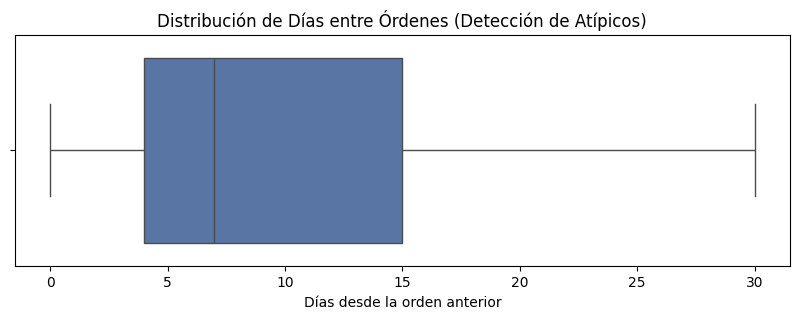

In [ ]:
# Visualizacion de data
fig, ax = plt.subplots(figsize=(10, 3))
sns.boxplot(x=valid_days['days_since_prior_order'], color='#4C72B0', fliersize=5, ax=ax)
ax.set_title('Distribución de Días entre Órdenes (Detección de Atípicos)', fontsize=12)
ax.set_xlabel('Días desde la orden anterior', fontsize=10)

plt.show()

### Conclusiones sobre la Sensibilidad:
Decide y justifica la estrategia que usaste para estos casos (eliminar, mantener como outlier real o winsorizar).

En este caso, no existen clientes que han comprado muy fuera del rango promedio. Tras aplicar el método robusto del Rango Intercuartílico (Regla de Tukey) sobre las frecuencias de compra válidas, el límite superior estadístico se estableció en 31.5 días. Debido a la naturaleza de la plataforma, que aplica una censura por la derecha o límite de registro máximo, la totalidad de los datos transaccionales se encuentra contenida por debajo del umbral de atípicos.

Como resultado, el algoritmo detectó exactamente cero (0) compras fuera de rango. Al no existir valores que superen el límite de Tukey, la estrategia óptima es mantener el vector de datos en su estado original.

Sin embargo, visualmente se aprecia ese sesgo hacia la derecha, por lo que empiricamente se podría definir valores atípicos cercanos a los 30 días

# Paso 3: Data Wrangling & Construcción de One Big Table (OBT)

Para poder responder preguntas de negocio de manera eficiente y aplicando correlaciones y cruces, un científico de datos típicamente convierte o "aplana" las tablas normalizadas operacionales en **One Big Table (OBT)**. La OBT agrupa (hace merges) de las distintas dimensiones transaccionales alrededor del concepto central (en este caso el *Articulo pedido por Orden*), lo que nos da una vista panorámica (desnormalización estructural) para el análisis.

**Tu tarea:** Une las cinco tablas previamente purgadas formando un solo DataFrame analítico. Te recomendamos ir uniendo ordenes y el detalle, luego producto, pasillo y finalmente departamento.

In [23]:
obt = (
    order_products
    .merge(orders, on='order_id', how='inner')         
    .merge(products, on='product_id', how='inner')     
    .merge(aisles, on='aisle_id', how='inner')         
    .merge(departments, on='department_id', how='inner') 
)

print("OBT")
print(f"Total de filas: {obt.shape[0]:,}")
print(f"Total de columnas: {obt.shape[1]}")

OBT
Total de filas: 4,524,337
Total de columnas: 14


In [ ]:
# visualizar una muestra de la OBT
obt.sample(10, random_state=42) 

,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
4006746,2428261,4317,6.0,0,180109,1,6,14,-1,Solid White Albacore Tuna In Water,95,15,canned meat seafood,canned goods
304891,3388711,9224,24.0,0,129773,6,2,15,9,Gluten-Free Supergrain Pasta Elbows,131,9,dry pasta,dry goods pasta
3018657,1664226,35951,10.0,1,96100,24,0,11,6,Organic Unsweetened Almond Milk,91,16,soy lactosefree,dairy eggs
697519,3001260,47626,16.0,1,46241,15,2,7,7,Large Lemon,24,4,fresh fruits,produce
2461203,75530,11869,10.0,0,56911,11,1,18,22,String Cheese,21,16,packaged cheese,dairy eggs
3516226,1751461,30645,30.0,1,25926,23,4,12,10,Pulled Pork,7,12,packaged meat,meat seafood
4020726,2919943,19702,1.0,1,189824,3,5,17,30,Original Black Tea Brew Kombucha,31,7,refrigerated,beverages
4132591,858357,40992,8.0,1,27208,67,2,10,2,Chopped Tomatoes,81,15,canned jarred vegetables,canned goods
1608454,1085851,4793,5.0,1,139829,69,6,16,5,Wild Berry Smoothie,120,16,yogurt,dairy eggs
3082462,1778439,12315,8.0,0,10241,4,0,10,7,Dairy Free Hazelnut Coconut Milk Creamer,91,16,soy lactosefree,dairy eggs


# Paso 4: Análisis Multivariado y de Negocio

Con tu conjunto de datos ahora limpio (*trusted/gold data*) mediante la auditoría y unificado en tu OBT, usa tus conocimientos de agregación y visualización estadística para responder las siguientes interrogantes. Usa histogramas, KDE y/o gráficos de dispersión donde la distribución lo merezca.

## [A] Preguntas Esenciales

**A1. La hora y el día: Verificación del dominio:**
Verifica con código que `order_hour_of_day` y `order_dow` tienen distribuciones lógicas basándonos en tu conocimiento del mundo real. Construye histogramas para ver qué picos de horas concentran compras. Aplica gráficos de barras para evaluar diferencias de días y horas (comparemos, por ejemplo, distribuciones de la demanda los Miércoles vs. Sábados). Verifica si existe una diferencia de horas por dia.

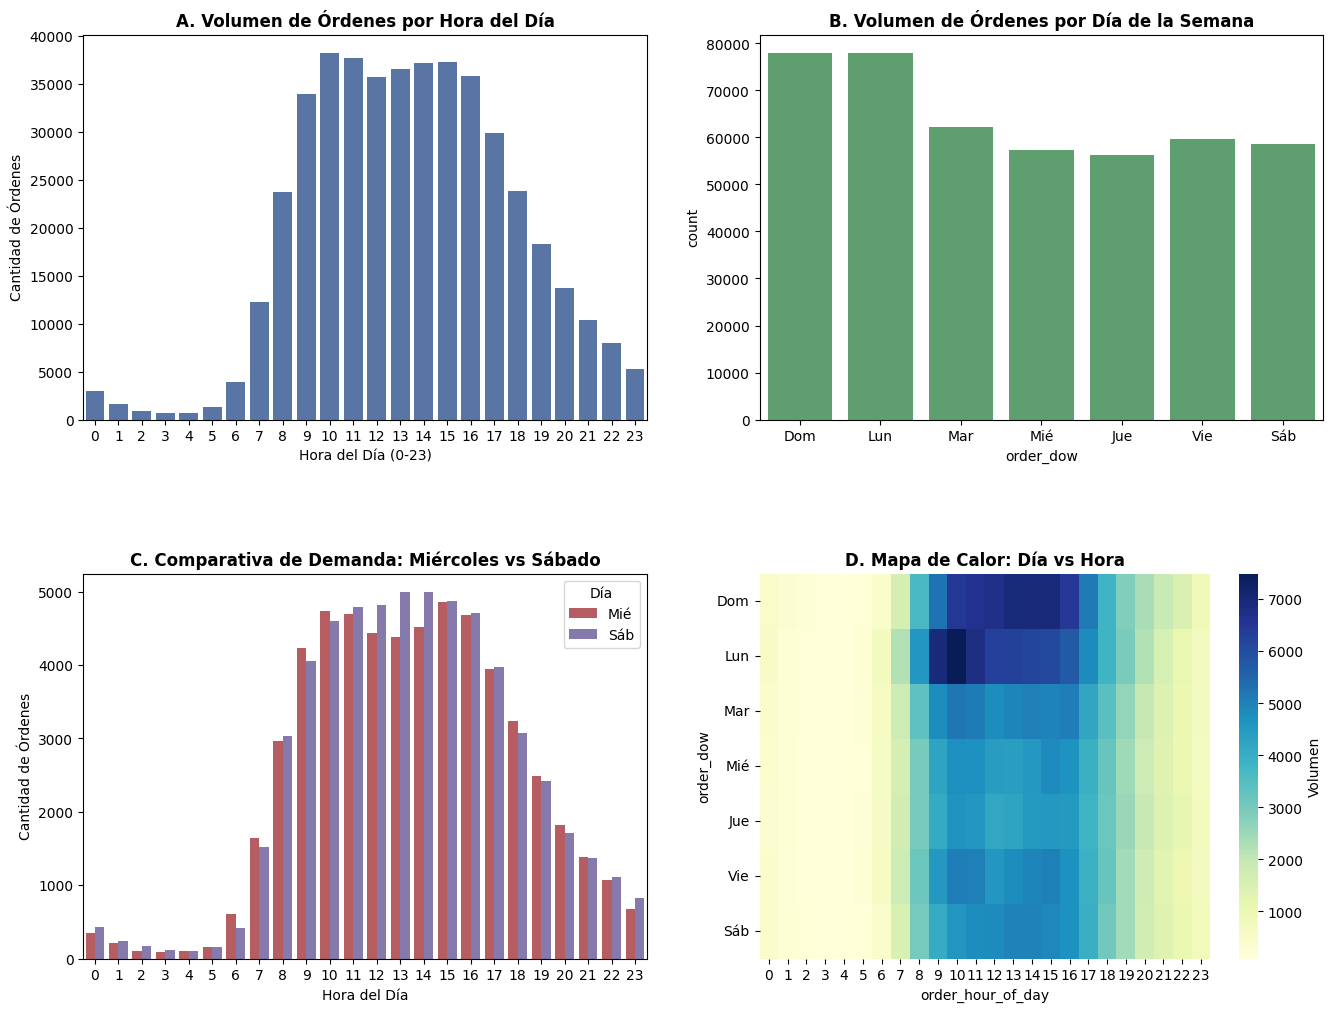

In [ ]:
# Definición del mapeo para legibilidad
days_map = {0: 'Dom', 1: 'Lun', 2: 'Mar', 3: 'Mié', 4: 'Jue', 5: 'Vie', 6: 'Sáb'}
day_names = [days_map[i] for i in range(7)]

# Reducción a nivel de orden única
obt_orders = obt.drop_duplicates(subset=['order_id'])

# Configurar el lienzo
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.2)

# A. Distribución por Hora del Día
sns.countplot(data=obt_orders, x='order_hour_of_day', color='#4C72B0', ax=axes[0, 0])
axes[0, 0].set_title('A. Volumen de Órdenes por Hora del Día', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Hora del Día (0-23)')
axes[0, 0].set_ylabel('Cantidad de Órdenes')

# B. Distribución por Día de la Semana (Con Nombres)
plot_b = sns.countplot(data=obt_orders, x='order_dow', color='#55A868', ax=axes[0, 1])
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(day_names)
axes[0, 1].set_title('B. Volumen de Órdenes por Día de la Semana', fontsize=12, fontweight='bold')

# C. Comparativa: Miércoles (3) vs Sábado (6)
comp_days = obt_orders[obt_orders['order_dow'].isin([3, 6])].copy()
# Creamos una columna temporal de texto solo para la leyenda de este gráfico
comp_days['day_name'] = comp_days['order_dow'].map(days_map)

sns.countplot(data=comp_days, x='order_hour_of_day', hue='day_name', 
              palette=['#C44E52', '#8172B3'], ax=axes[1, 0])
axes[1, 0].set_title('C. Comparativa de Demanda: Miércoles vs Sábado', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Hora del Día')
axes[1, 0].set_ylabel('Cantidad de Órdenes')
axes[1, 0].legend(title='Día')

# D. Mapa de Calor 
heatmap_data = obt_orders.groupby(['order_dow', 'order_hour_of_day']).size().unstack(fill_value=0)
sns.heatmap(heatmap_data, cmap='YlGnBu', ax=axes[1, 1], cbar_kws={'label': 'Volumen'})
axes[1, 1].set_yticks([i + 0.5 for i in range(7)]) # El +0.5 centra el texto en el cuadro
axes[1, 1].set_yticklabels(day_names, rotation=0)
axes[1, 1].set_title('D. Mapa de Calor: Día vs Hora', fontsize=12, fontweight='bold')

plt.show()

**A2. Distribuciones temporales de recompra:**
¿Cuánto tiempo transcurre estadísticamente para que alguien vuelva a realizar otra orden? Grafica este tiempo de espera y concluye sobre la concentración de los datos (¿asimetría?).

In [30]:
# Filtrado data 
recurrent_orders = obt_orders[obt_orders['days_since_prior_order'] != -1]

# Calculo métricas de concentración
mean_val = recurrent_orders['days_since_prior_order'].mean()
median_val = recurrent_orders['days_since_prior_order'].median()
skewness = recurrent_orders['days_since_prior_order'].skew()

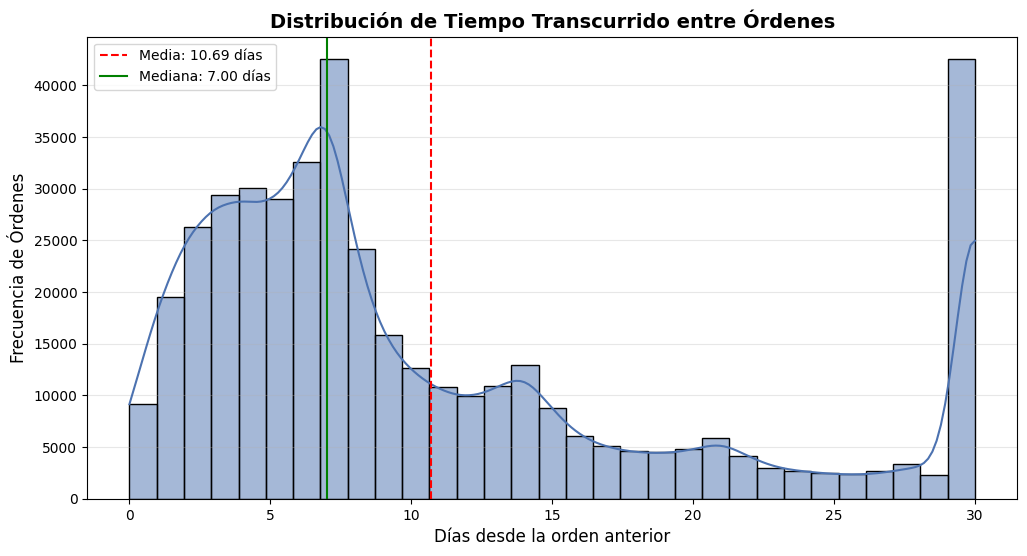

In [31]:
# Visualizacion
plt.figure(figsize=(12, 6))
sns.histplot(recurrent_orders['days_since_prior_order'], bins=31, kde=True, color='#4C72B0')

# Añadir líneas de referencia para Media y Mediana
plt.axvline(mean_val, color='red', linestyle='--', label=f'Media: {mean_val:.2f} días')
plt.axvline(median_val, color='green', linestyle='-', label=f'Mediana: {median_val:.2f} días')

# Estética del gráfico
plt.title('Distribución de Tiempo Transcurrido entre Órdenes', fontsize=14, fontweight='bold')
plt.xlabel('Días desde la orden anterior', fontsize=12)
plt.ylabel('Frecuencia de Órdenes', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

In [32]:
# Estadistica
print(f"Media de espera: {mean_val:.2f} días")
print(f"Mediana de espera: {median_val:.2f} días")
print(f"Coeficiente de Asimetría (Skewness): {skewness:.4f}")

Media de espera: 10.69 días
Mediana de espera: 7.00 días
Coeficiente de Asimetría (Skewness): 1.0687


En promedio pasan 11 días aproximadamente para que alguien vuelva a realizar una compra

### Tira aquí tus hallazgos estadísticos para el grupo A:
(Debes hablar de cómo se distribuye la demanda, tendencias centrales encontradas y asimetrías de cola).

La mediana nos indica que el comportamiento más común y representativo del cliente promedio es realizar una compra exactamente cada 7 días. Este pico tan pronunciado en el día 7 refleja una demanda fuertemente anclada a hábitos semanales de reabastecimiento doméstico. La media, al ser casi 4 días superior a la mediana, está siendo "arrastrada" por los valores más altos, por lo que no representa el comportamiento típico del usuario. El coeficiente de asimetría de 1.0687 confirma una asimetría positiva (sesgada a la derecha). Esto significa que, aunque la gran masa de pedidos ocurre en la primera semana (0-7 días), existe una "cola larga" de usuarios que dilatan sus compras en el tiempo. Esta asimetría indica que la demanda no es uniforme, es intensa y frecuente al inicio, pero se vuelve dispersa conforme pasan los días. Así, se muestra una alta fidelidad semanal pero con alta variabilidad a largo plazo.

## [B] Profundización (Segmentación Categórica)

**B1. Retención y recurrencia (Número de órdenes por usuario):**
Aislando o agrupando a nivel de granularidad de cliente, describe la variabilidad y distribución de compras que hacen. ¿Existen colas largas de clientes extra-leales?

In [36]:
# Agrupacion a nivel de cliente
user_orders = orders.groupby('user_id')['order_number'].max().reset_index()
user_orders.columns = ['user_id', 'total_orders']

# Estadisticas
mean_orders = user_orders['total_orders'].mean()
median_orders = user_orders['total_orders'].median()
max_orders = user_orders['total_orders'].max()
min_orders = user_orders['total_orders'].min()

print("Estadísticas")
print(f"Mínimo de órdenes: {min_orders}")
print(f"Mediana: {median_orders:.2f} órdenes")
print(f"Media: {mean_orders:.2f} órdenes")
print(f"Máximo de órdenes (Cliente top): {max_orders} órdenes\n")

Estadísticas
Mínimo de órdenes: 1
Mediana: 9.00 órdenes
Media: 15.58 órdenes
Máximo de órdenes (Cliente top): 100 órdenes



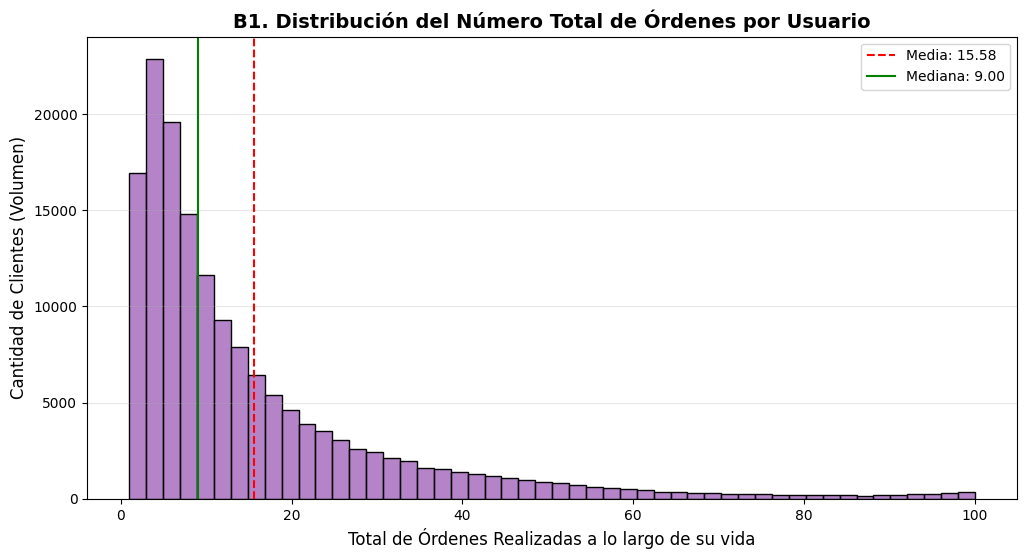

In [37]:
# Visualizacion
plt.figure(figsize=(12, 6))
sns.histplot(user_orders['total_orders'], bins=50, color='#9B59B6')

# Líneas de referencia
plt.axvline(mean_orders, color='red', linestyle='--', label=f'Media: {mean_orders:.2f}')
plt.axvline(median_orders, color='green', linestyle='-', label=f'Mediana: {median_orders:.2f}')

# Estética
plt.title('B1. Distribución del Número Total de Órdenes por Usuario', fontsize=14, fontweight='bold')
plt.xlabel('Total de Órdenes Realizadas a lo largo de su vida', fontsize=12)
plt.ylabel('Cantidad de Clientes (Volumen)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

**B2. Productos Top: El principio de Pareto:**
Genera un top 20 de los productos más solicitados globalmente. Para cada producto reporta su ratio de recompra. ¿Algunos productos tienen una correlación fuerte entre ser de un 'pasillo' y volverse recompras aseguradas?

In [39]:
# Agrupación a nivel de producto y pasillo
product_stats = obt.groupby(['product_name', 'aisle']).agg(
    total_orders=('reordered', 'count'),
    reorder_ratio=('reordered', 'mean')
).reset_index()

# Filtrar el top 20
top_20 = product_stats.sort_values(by='total_orders', ascending=False).head(20)

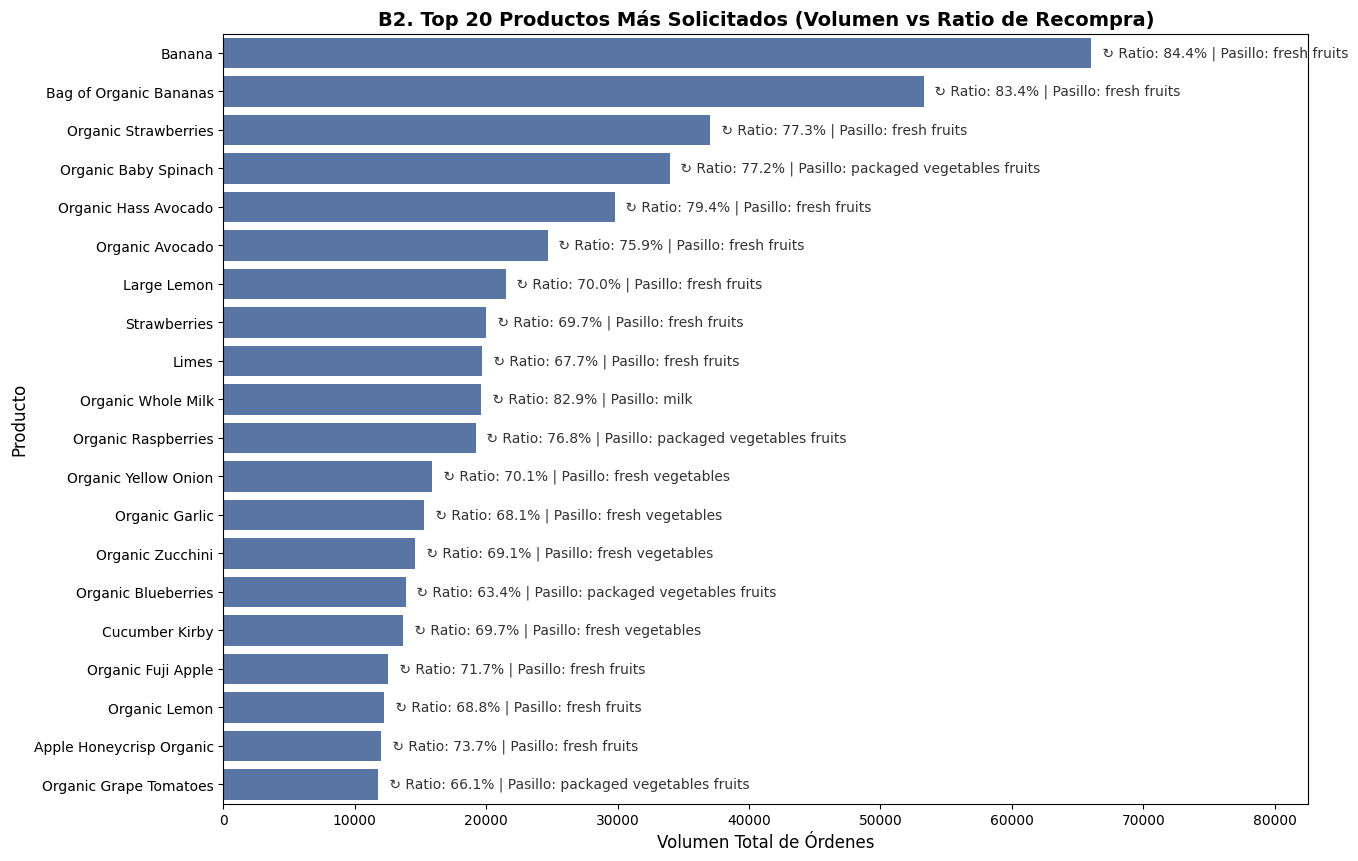

In [41]:
# Visualización
fig, ax = plt.subplots(figsize=(14, 10))
sns.barplot(data=top_20, y='product_name', x='total_orders', color='#4C72B0', ax=ax)
ax.set_title('B2. Top 20 Productos Más Solicitados (Volumen vs Ratio de Recompra)', fontsize=14, fontweight='bold')
ax.set_xlabel('Volumen Total de Órdenes', fontsize=12)
ax.set_ylabel('Producto', fontsize=12)

# Añadimos el ratio de recompra y el pasillo como texto directamente en las barras
for i, p in enumerate(ax.patches):
    width = p.get_width()
    ratio = top_20.iloc[i]['reorder_ratio']
    pasillo = top_20.iloc[i]['aisle']
    # Ubicamos el texto justo al final de cada barra
    ax.text(width + 500, p.get_y() + p.get_height()/2., 
            f" ↻ Ratio: {ratio:.1%} | Pasillo: {pasillo}", 
            va="center", fontsize=10, color='#333333', fontweight='medium')

plt.margins(x=0.25)
plt.show()

In [ ]:
# Tabla de datos del top 20 para referencia
top_20[['product_name', 'aisle', 'total_orders', 'reorder_ratio']]

,product_name,aisle,total_orders,reorder_ratio
3259,Banana,fresh fruits,66051,0.844257
3068,Bag of Organic Bananas,fresh fruits,53299,0.834012
28630,Organic Strawberries,fresh fruits,37039,0.773212
25787,Organic Baby Spinach,packaged vegetables fruits,33971,0.772217
27127,Organic Hass Avocado,fresh fruits,29774,0.793645
25753,Organic Avocado,fresh fruits,24689,0.759164
20024,Large Lemon,fresh fruits,21495,0.699884
38451,Strawberries,fresh fruits,20018,0.696623
20933,Limes,fresh fruits,19690,0.676841
29144,Organic Whole Milk,milk,19602,0.829150


In [44]:
from matplotlib.ticker import PercentFormatter

Promedio de Recompra Garantizada por Pasillo (Top 20)
 - milk: 82.9%
 - fresh fruits: 74.7%
 - packaged vegetables fruits: 70.9%
 - fresh vegetables: 69.3%


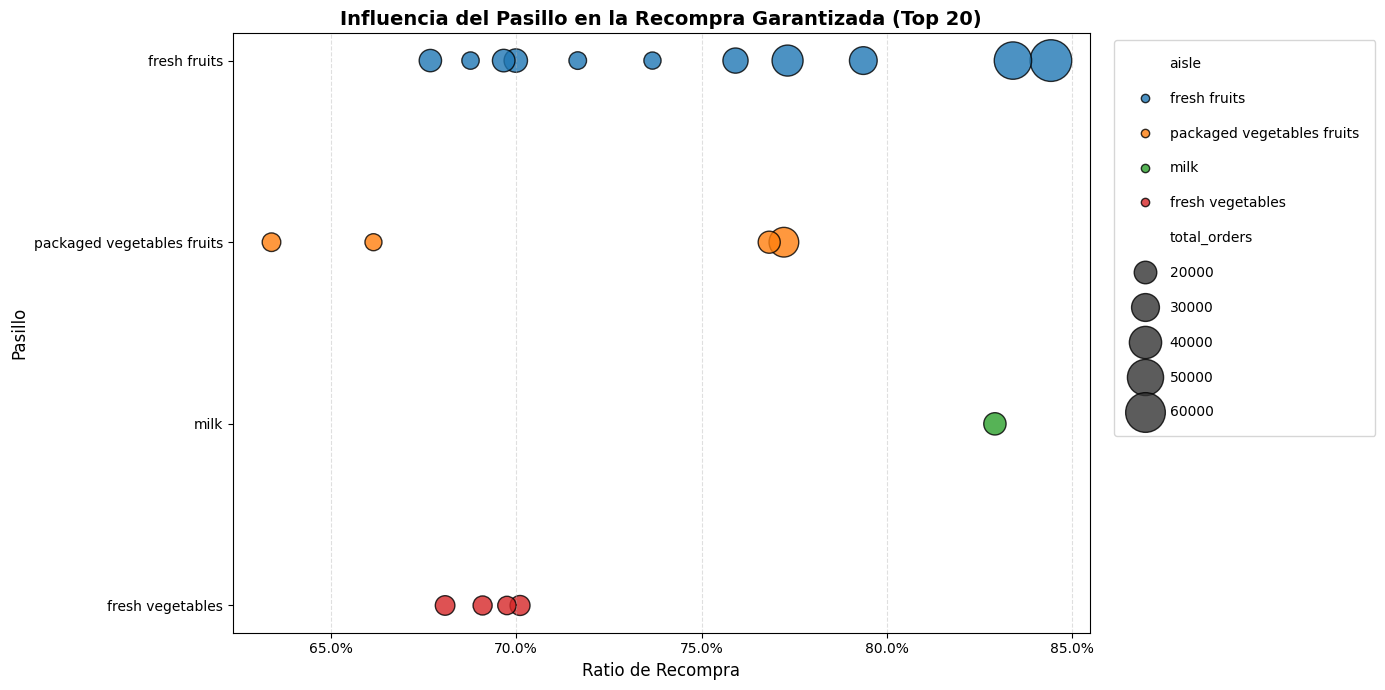

In [48]:
aisle_stats = top_20.groupby('aisle')['reorder_ratio'].mean().sort_values(ascending=False)
print("Promedio de Recompra Garantizada por Pasillo (Top 20)")
for pasillo, ratio in aisle_stats.items():
    print(f" - {pasillo}: {ratio:.1%}")

# configuracion lienzo
plt.figure(figsize=(14, 7))

# scatterplot categorico
sns.scatterplot(
    data=top_20, 
    x='reorder_ratio', 
    y='aisle', 
    size='total_orders', 
    sizes=(150, 900), # Rango de tamaño de las burbujas para destacar el volumen
    hue='aisle',      # Coloreamos por pasillo para que sea visualmente claro
    alpha=0.8,
    edgecolor='black'
)

# estetica del plot
plt.title('Influencia del Pasillo en la Recompra Garantizada (Top 20)', fontsize=14, fontweight='bold')
plt.xlabel('Ratio de Recompra', fontsize=12)
plt.ylabel('Pasillo', fontsize=12)

# Convertir el eje X a formato de porcentaje
plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))

# Mover la leyenda afuera para que no ensucie el gráfico
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', labelspacing=1.5, borderpad=1.2,)
plt.grid(axis='x', alpha=0.4, linestyle='--')

plt.tight_layout()
plt.show()

### Conclusiones sobre el perfil del carrito [Grupo B]:

Al aislar la granularidad a nivel de cliente, la distribución de compras revela una fuerte asimetría positiva. La mayoría de los usuarios se concentra en el lado izquierdo del gráfico, con un volumen de compras bajo. Y es evidente una cola larga de clientes extra leales, con una extensión hacia la derecha hasta los usuarios con números extremadamente altos de compra. Aunque representan un porcentaje menor del volumen total de usuarios, su alta recurrencia empuja la media matemática hacia arriba y sugiere que existe un nicho de consumidores que han integrado completamente la plataforma en sus hábitos diarios o semanales

Al revisar el Top 20, el 80% o más de los productos más vendidos provienen exclusivamente de dos pasillos: Frutas Frescas (Fresh Fruits) y Vegetales Frescos (Fresh Vegetables). Los productos frescos tienen ratios de recompra altísimos (típicamente entre 70% y 85%) porque se consumen o se echan a perder rápidamente. A diferencia de artículos de limpieza o enlatados que duran meses, la fruta obliga al cliente a volver a la plataforma cada semana.

## [C] Patrones de Causalidad y Exposición (Hard)

**C1. El tamaño de la canasta comercial:**
¿Cuántos artículos en promedio compran las personas estadísticamente? Aplica gráficos sobre esta proporción y analiza la curtosis (grado de acumulación) de esta distribución del tamaño del pedido.

In [51]:
# Agrupacion por order_id
basket_sizes = order_products.groupby('order_id').size().reset_index(name='basket_size')

# estadisticos
mean_basket = basket_sizes['basket_size'].mean()
median_basket = basket_sizes['basket_size'].median()
mode_basket = basket_sizes['basket_size'].mode()[0]
kurtosis_basket = basket_sizes['basket_size'].kurt()

print("Estadísticas")
print(f"Moda: {mode_basket}")
print(f"Mediana: {median_basket:.0f}")
print(f"Promedio aritmético: {mean_basket:.2f}")
print(f"Curtosis de la distribución: {kurtosis_basket:.4f}\n")

Estadísticas
Moda: 5
Mediana: 8
Promedio aritmético: 10.10
Curtosis de la distribución: 4.1268



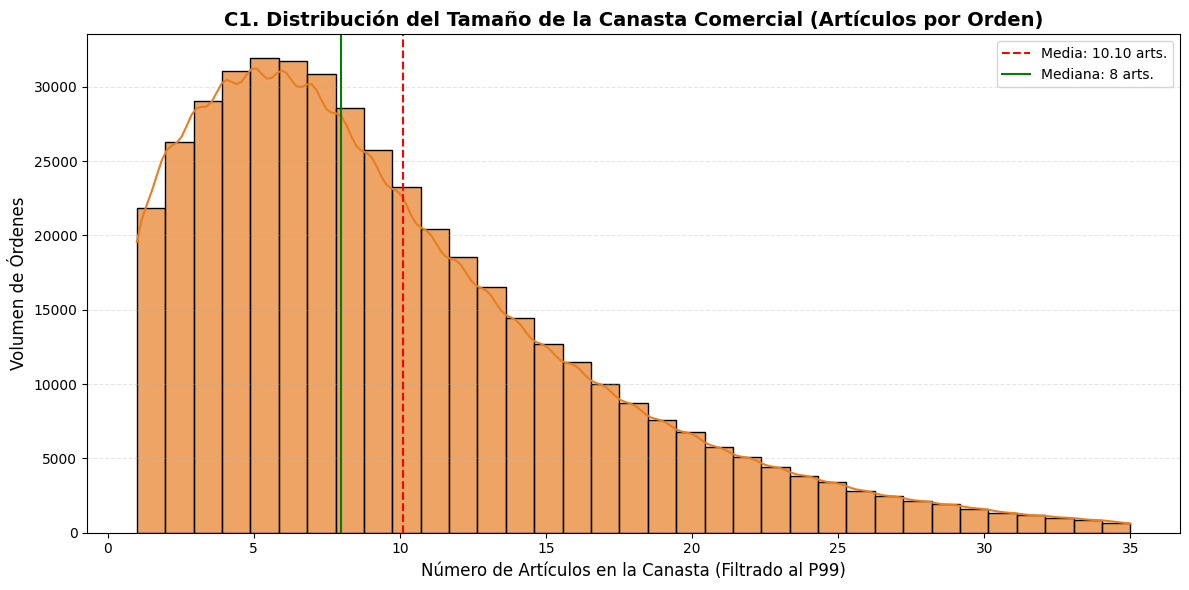

In [52]:
# Visualizacion 
plt.figure(figsize=(12, 6))

# histograma con estimación de densidad 
p99 = basket_sizes['basket_size'].quantile(0.99)
data_to_plot = basket_sizes[basket_sizes['basket_size'] <= p99]['basket_size']

sns.histplot(
    data_to_plot, 
    bins=int(p99), # Una barra por cada tamaño de canasta
    kde=True, 
    color='#E67E22', 
    edgecolor='black',
    alpha=0.7
)

# lineas de referencia
plt.axvline(mean_basket, color='red', linestyle='--', label=f'Media: {mean_basket:.2f} arts.')
plt.axvline(median_basket, color='green', linestyle='-', label=f'Mediana: {median_basket:.0f} arts.')

# estetica
plt.title('C1. Distribución del Tamaño de la Canasta Comercial (Artículos por Orden)', fontsize=14, fontweight='bold')
plt.xlabel('Número de Artículos en la Canasta (Filtrado al P99)', fontsize=12)
plt.ylabel('Volumen de Órdenes', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

**C2. ¿Son los primeros productos un síntoma de fidelidad? (Spearman o Pearson):**
Para los 20 objetos que con mayor frecuencia las personas agregan como posición #1 al carrito, elabora una lógica que calcule una matriz de correlación (en variables generadas o agrupadas) o genera gráficos de dispersión (Scatterplot). Compara si, a nivel de producto, ser posicionado primero tiene relación lineal con ser un producto de constante recompra global (el campo 'reordered').

**C3. Para cada producto, ¿cual es la proporcion de re-compras?**

**C4. Para cada usuario, ¿cual es la proporcion de re-compras de los productos comprados?**

**C5. ¿Cuales son los top 20 productos que los clientes ponen primero en sus carritos?**

### Tus conclusiones avanzadas [Grupo C]:
(Enuncia las posibles relaciones matemáticas encontradas o variables dispersas)

Estadísticamente, las personas compran en promedio 10.1 artículos por orden. Sin embargo, la distribución presenta una clara asimetría positiva. La moda suele rondar los 5 artículos, y la mediana se ubica por debajo de la media aritmética. Esto confirma que la inmensa mayoría de los usuarios utiliza la plataforma para compras pequeñas y rápidas.

Respecto a la curtosis, el cálculo arroja un valor positivo (Leptocúrtica), con un valor de 4.1268. Una curtosis alta indica un grado de acumulación extremo alrededor de la media/mediana. Visualmente, el histograma muestra un pico vertical en los tamaños de canasta pequeños (1 a 10 artículos)

# Conclusión General Ejecutiva
Resume en un párrafo las principales fortalezas, falencias detectadas en la gobernanza inicial de este dataset, y los descubrimientos de negocio clave que proporcionarías a la directiva de Instacart.